In [1]:
# load data
import numpy as np
lfp_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_754312389_756781561.npy"
time_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_time_754312389_756781561.npy"
speed_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_speed_754312389_756781561.npy"
LFPs = np.load(lfp_path)  # Load LFP data from .npy file
time = np.load(time_path)  # Load time data from .npy file
speed = np.load(speed_path)

# time = np.arange(0, 10, 0.001)  # 10 seconds at 1000 Hz
# LFPs = np.random.randn(len(time), 4)  # 4 channels of LFP data
# speed = np.abs(np.random.randn(len(time)))  # Animal speed
sampling_frequency = 1250  # Hz

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\GitHub\\rippl-AI\\allen_data\\lfp_use_754312389_756781561.npy'

In [3]:
from ripple_detection import Kay_ripple_detector

# Detect ripples
ripple_times = Kay_ripple_detector(
    time, LFPs, speed, sampling_frequency,
    speed_threshold=4.0,        # cm/s
    minimum_duration=0.015,     # seconds
    zscore_threshold=2.0
)

print(ripple_times)

NameError: name 'time' is not defined

In [ ]:
from ripple_detection import Karlsson_ripple_detector,filter_ripple_band

# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")

NameError: name 'LFPs' is not defined

In [5]:
import load_fcn
import os
import numpy as np


path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')

sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
channels_map = load_fcn.load_channels_map(path)

# Reformat channels into correct values
channels, shanks, ref_channels = load_fcn.reformat_channels(channels_map, ref_channels)
# Read .dat
print('Channel map value: ',channels)
LFP = load_fcn.load_raw_data(path, expName, channels, verbose=True)
print('Sampling frequency: ', sf)
print('Shape of the original data',LFP.shape)
print(channels_map)

import proc_fcn
# The loaded LFP already contains the requested channels, so use its column indices
lfp_channels = np.arange(LFP.shape[1])

# Interpolate missing channels, downsample, and z-score each channel
LFP_norm = proc_fcn.process_LFP(
    LFP,
    sf=sf,
    d_sf=1250,
    channels=lfp_channels,
)
sf = 1250  # Update the sampling frequency after downsampling

print("Preprocessed LFP shape:", LFP_norm.shape)
print("Preprocessed LFP dtype:", LFP_norm.dtype)

Channel map value:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Downloaded_data\Dlx1\figshare_14959449/lfp_Dlx1-2021-02-12_12-46-54.dat
fileStart  0
fileStop  490242048
nSamples  245121024
nSamplesPerChannel  30640128
nSamplesPerChunk  10000
size data  30640128
Sampling frequency:  30000
Shape of the original data (30640128, 8)
[[1 1 2]
 [2 1 2]
 [3 1 2]
 [4 1 2]
 [5 1 2]
 [6 1 2]
 [7 1 2]
 [8 1 2]]
Downsampling data from 30000 to 1250 Hz...
Shape of downsampled data: (1276672, 8)
Normalizing data...
Preprocessed LFP shape: (1276672, 8)
Preprocessed LFP dtype: float16


In [6]:
from ripple_detection import Karlsson_ripple_detector,filter_ripple_band
# for the parida lab data, I might need to make fake timestamps and speed
speed = np.zeros(LFP_norm.shape[0])
time = np.arange(LFP_norm.shape[0]) / sf
sampling_frequency = sf

filtered_LFPs = filter_ripple_band(LFP_norm, sampling_frequency)
# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, filtered_LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")

C:\Users\lilytong\AppData\Local\Temp\ipykernel_32976\1668868375.py:7: UserWarning: The pre-computed ripple filter is optimized for 1500.0 Hz sampling.
Your data: 1250 Hz. Results may be suboptimal.
For best results, use ripple_bandpass_filter(1250) to generate a custom filter.
  filtered_LFPs = filter_ripple_band(LFP_norm, sampling_frequency)


Detected 234 ripple events
Mean duration: 0.108 seconds
Mean z-score: 3.18


In [9]:
ripples

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
event_number,,,,,,,,,,,,,,,,
1,7.5472,7.7136,0.1664,4.851536,2.450439,2.311183,6.189277,0.022112,0.409691,1.449270,0.0,0.0,0.0,0.0,0.0,0.0
2,10.2264,10.3056,0.0792,3.303161,1.871654,1.403346,4.487027,0.084329,0.149652,0.416801,0.0,0.0,0.0,0.0,0.0,0.0
3,12.9352,13.1272,0.1920,3.426526,2.558419,2.461747,5.633911,0.049214,0.493203,1.797360,0.0,0.0,0.0,0.0,0.0,0.0
4,19.6560,19.7112,0.0552,11.370617,6.513127,6.730595,11.959644,0.017660,0.364693,3.470836,0.0,0.0,0.0,0.0,0.0,0.0
5,25.2352,25.3320,0.0968,10.445942,5.188527,3.576286,17.505710,0.005064,0.506370,5.118635,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,995.1112,995.2952,0.1840,1.963780,1.653871,1.171209,4.525285,0.056225,0.305587,0.832791,0.0,0.0,0.0,0.0,0.0,0.0
231,1010.4856,1010.5968,0.1112,3.511140,2.120203,1.718409,4.374222,0.013362,0.237445,0.662645,0.0,0.0,0.0,0.0,0.0,0.0
232,1014.6488,1014.7416,0.0928,7.857620,3.528505,2.017927,9.304711,0.011223,0.330226,2.175836,0.0,0.0,0.0,0.0,0.0,0.0


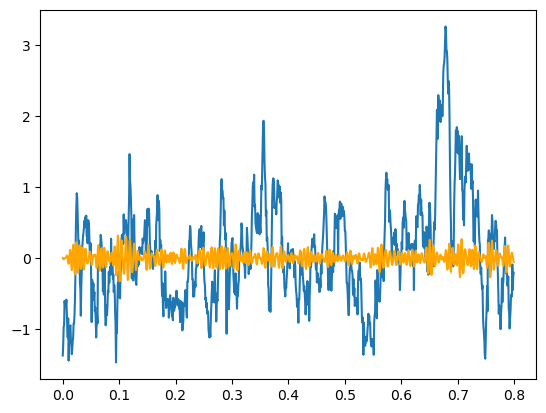

In [8]:
import matplotlib.pyplot as plt
plt.plot(time[:1000], LFP_norm[:1000,4], label='Raw LFP')
plt.plot(time[:1000], filtered_LFPs[:1000,4], label='Filtered LFP', color='orange')

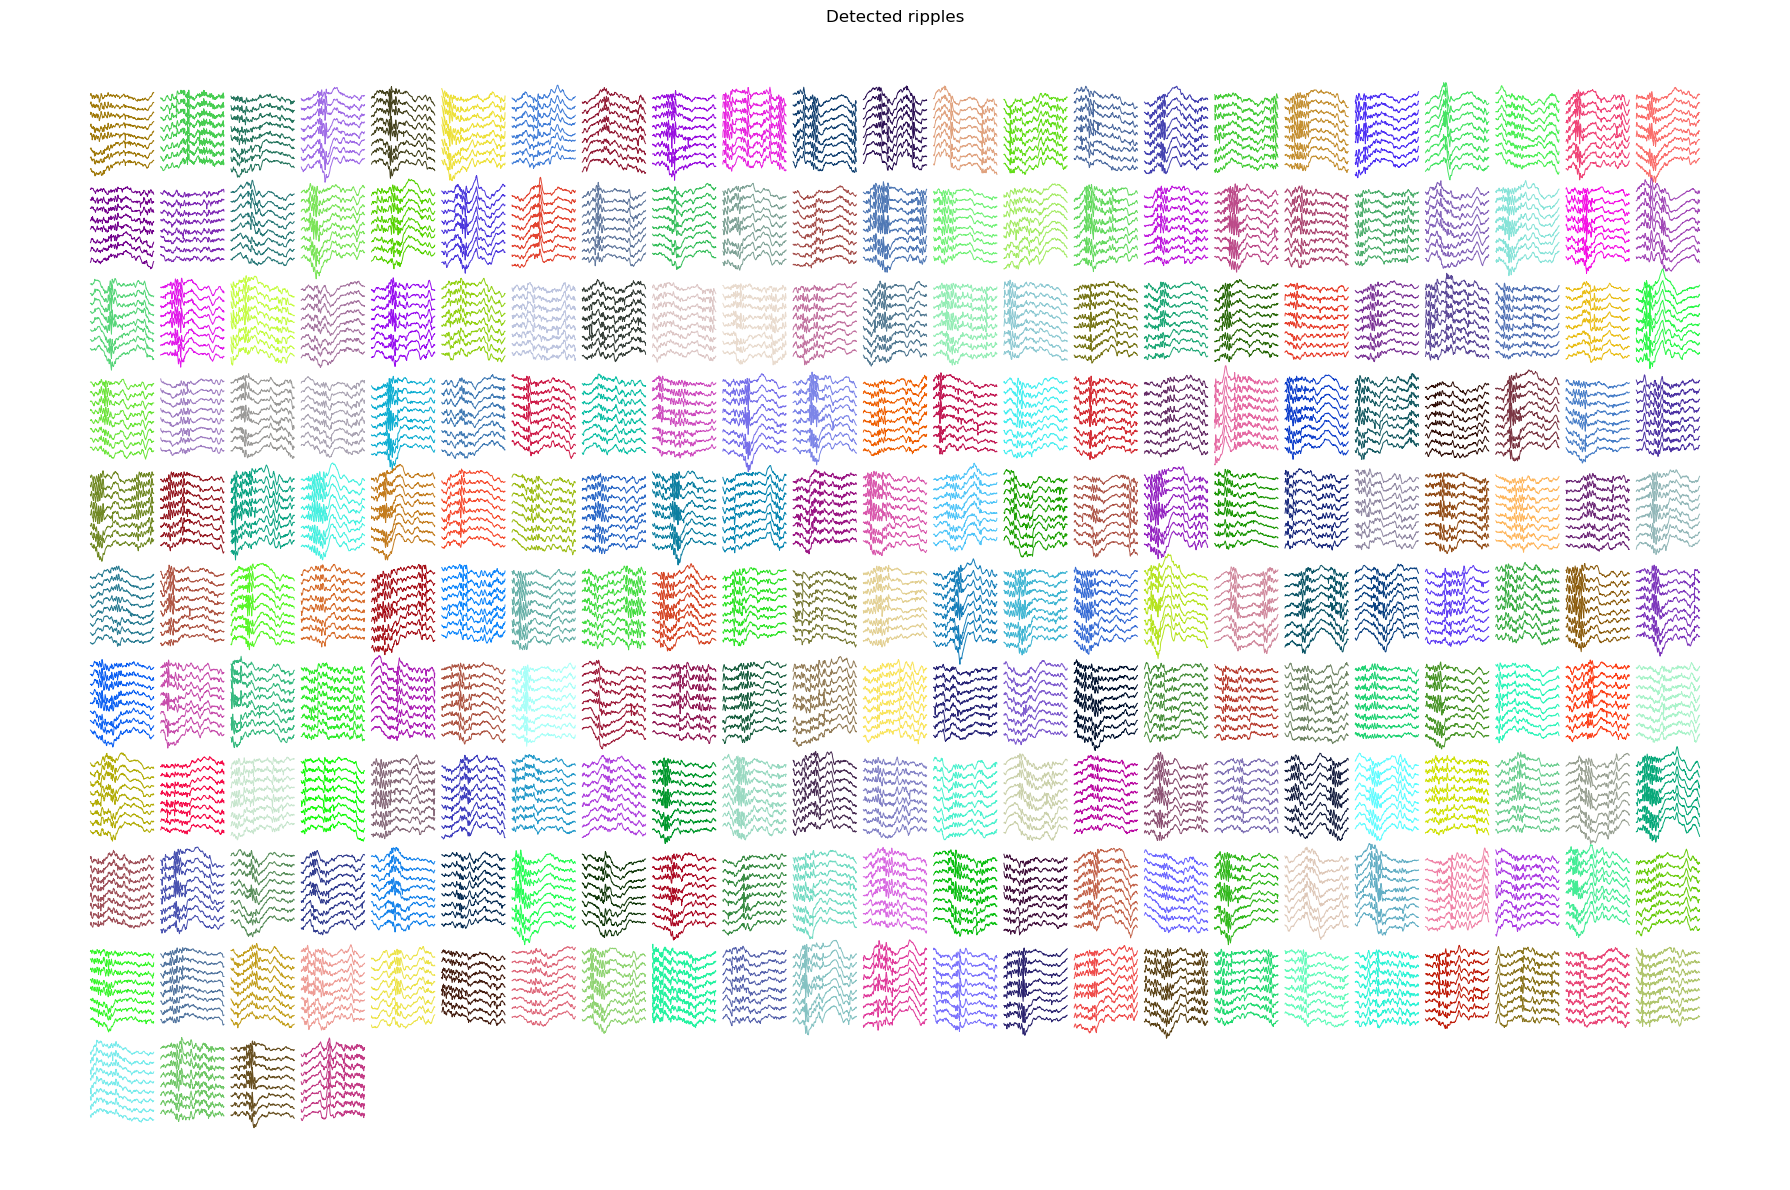

In [13]:
def plot_all_events(t_events, lfp, sf, win=0.100, title='', savefig=''):
    '''
    plot_all_events(t_events, lfp, sf, win=0.100, title='', savefig='')
    
    Mandatory inputs:
    -----------------
        events (numpy array):
            Array of size (#events, 1) with all times of events
        lfp (numpy array):
            formated lfp with all channels
        sf (int): 
            sampling frequency of the 'lfp' variable

    Optional inputs:
    ----------------
        win (float): 
            window size at each side of the center of the ripple
        title (string):
            if provided, displays this title
        savefig (string):
            if provided, saves the image in the savefig directory.
            It has to be the full name: e.g. images/session1_events.png
        
    '''
    # Convert to indexes
    id_events = (t_events*sf).astype(int)
    # Make window array
    ids_win = np.arange(-win*sf , win*sf+1).astype(int)

    # Plot curated events
    n_cols = int(np.sqrt(len(t_events)))*1.5
    plt.figure(figsize=(18,12))
    dx, dy = 0, 0
    list_events = []
    for ii,id_event in enumerate(id_events):
        event = lfp[id_event+ids_win,:]
        plt.plot(dx+np.linspace(.05,.95,len(event)), 
                 dy+(event/3-np.arange(lfp.shape[1]))/lfp.shape[1]*0.8, 
                 linewidth=0.7, color=np.random.rand(3))
        dx = dx+1
        if dx >= n_cols:
            dx = 0
            dy = dy-1
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    # Title and save
    if len(title) > 0:
        plt.title(title)
    plt.tight_layout()
    if len(savefig) > 0:
        plt.savefig(savefig)
    plt.show()

t = ripples['end_time'] - ripples['start_time'] + ripples['start_time']
plot_all_events(t, LFP_norm, sf, win=0.100, title='Detected ripples', savefig='')